# ⚽ Mundial 2026 — ¿Cuánto predice SOLO el juego?
## La misma metodología, prohibiendo Elo, plantilla y head-to-head

**Experimento:** ¿hasta dónde se puede predecir un partido mirando únicamente **lo que pasa en la
cancha** — goles, tiros, posesión, córners y faltas de los últimos 8 partidos — sin ratings
históricos, sin valor de mercado, sin historia del cruce?

Este notebook replica **exactamente** la metodología del entregable principal
(`Mundial_2026_Metodologia.ipynb`): mismas 5,023 observaciones, misma validación temporal, misma
selección de variables, mismos 14 modelos, misma simulación Monte Carlo del torneo. Lo único que
cambia es el menú: **7 candidatas, todas de juego**. El modelo completo aparece solo como *vara de
comparación* (fuera de concurso), y al final (§11) los dos Mundiales simulados se enfrentan.

**Índice:** Carga → EDA → Selección de variables → Entrenamiento (split temporal) → Significancia →
Matriz de confusión → Tratamiento del empate → ROC → Modelos alternativos → Simulación → Poisson →
**Comparación contra el modelo completo** → Conclusiones.

## 0 · Configuración

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); np.random.seed(42)
SEED = 42
print('Listo.')

Listo.


## 1 · Carga de datos y variables candidatas

Mismo universo que el notebook principal: **5,023 partidos (ene-2019 → 9-jun-2026)**. Pero esta vez
el menú de candidatas son solo las **7 variables de juego** (`diff` = local − visita), todas
calculadas con ventana móvil *walk-forward* de los últimos 8 partidos:

| Grupo | Variables | Qué miden |
|---|---|---|
| **Producción** | `goles_anotados_diff`, `goles_recibidos_diff` | ataque y defensa recientes |
| **Volumen ofensivo** | `tiros_diff`, `tiros_arco_diff`, `corners_diff` | cuánto genera el equipo |
| **Estilo** | `posesion_diff`, `faltas_diff` | control del balón y fricción |

> **Prohibidas en este experimento:** `elo_diff`, `squad_value_diff`, `ea_overall_diff` y `h2h_diff`.
> El target se mira desde el local: `2` Victoria, `1` Empate, `0` Derrota.

In [2]:
df = pd.read_csv('../data/modelado_espn.csv', parse_dates=['fecha']).sort_values('fecha').reset_index(drop=True)
CAND = ['goles_anotados_diff', 'goles_recibidos_diff', 'tiros_diff', 'tiros_arco_diff',
        'corners_diff', 'posesion_diff', 'faltas_diff']
COMPLETO = ['elo_diff', 'h2h_diff', 'squad_value_diff']   # el set del modelo principal (solo referencia)
data = df.dropna(subset=CAND).reset_index(drop=True)
print(f"Usables: {len(data):,} ({data.fecha.min().date()} -> {data.fecha.max().date()}) | "
      f"target: {data.resultado.value_counts(normalize=True).round(3).sort_index().to_dict()}")
data[['fecha', 'local', 'visita'] + CAND + ['resultado']].head()

Usables: 5,023 (2019-01-02 -> 2026-06-09) | target: {0: 0.279, 1: 0.275, 2: 0.446}


,fecha,local,visita,goles_anotados_diff,goles_recibidos_diff,tiros_diff,tiros_arco_diff,corners_diff,posesion_diff,faltas_diff,resultado
0,2019-01-02,Thailand,Oman,0.10,-0.20,0.00,0.00,0.00,0.00,0.00,0
1,2019-01-08,Sweden,Finland,0.00,0.33,-1.83,0.27,-0.23,-4.07,-3.50,0
2,2019-01-11,Sweden,Iceland,0.00,-0.82,0.93,0.13,-0.10,7.29,1.60,1
3,2019-01-11,Finland,Estonia,-0.33,-0.21,3.00,0.90,0.20,12.15,-1.67,0
4,2019-01-15,Iceland,Estonia,-0.15,0.91,0.45,1.07,0.33,2.08,-6.98,1


## 2 · Análisis exploratorio (EDA)

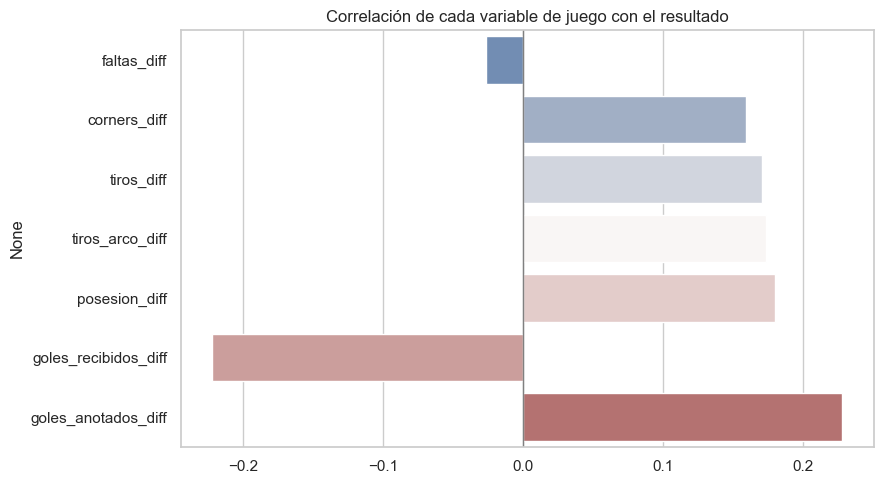

La producción reciente (goles anotados/recibidos, ±0.22) lidera; el volumen ofensivo y la
posesión aportan menos (~0.15); las faltas, prácticamente nada. Ninguna se acerca al 0.51
que mostraba elo_diff en el notebook principal — el experimento parte cuesta arriba, a propósito.


In [3]:
cy = data[CAND].corrwith(data['resultado']).sort_values(key=abs)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=cy.values, y=cy.index, palette='vlag', ax=ax); ax.axvline(0, color='grey', lw=1)
ax.set_title('Correlación de cada variable de juego con el resultado'); plt.tight_layout(); plt.show()
print('La producción reciente (goles anotados/recibidos, ±0.22) lidera; el volumen ofensivo y la')
print('posesión aportan menos (~0.15); las faltas, prácticamente nada. Ninguna se acerca al 0.51')
print('que mostraba elo_diff en el notebook principal — el experimento parte cuesta arriba, a propósito.')

## 3 · Selección de variables (sin fuga) — el corazón del trabajo

Idéntico protocolo que el notebook principal: **(A)** quitar redundantes por **VIF**, **(B)**
selección **forward** por log-loss con CV temporal (`TimeSeriesSplit`), **(C)** significancia (§5).
La selección solo ve el **train (<2025)** — elegir variables mirando el test, o con CV barajada,
es mirar el futuro.

In [4]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.dummy import DummyClassifier

CORTE_TEST = '2025-01-01'
train = data[data.fecha < CORTE_TEST].reset_index(drop=True)
y = train['resultado']
cv = TimeSeriesSplit(5)

def vifs(fs):
    X = sm.add_constant(train[fs])
    return {f: variance_inflation_factor(X.values, i + 1) for i, f in enumerate(fs)}

def ll(fs):
    p = Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=2000))])
    return -cross_val_score(p, train[fs], y, cv=cv, scoring='neg_log_loss').mean()

# (A) VIF iterativo
feats = CAND[:]; print('(A) VIF iterativo (quito la peor hasta VIF<5):')
while True:
    v = vifs(feats); p = max(v, key=v.get)
    if v[p] < 5: break
    print(f'   quito {p} (VIF={v[p]:.1f})'); feats.remove(p)
if len(feats) == len(CAND):
    print(f'   ninguna eliminada — VIF máximo: {max(vifs(feats).values()):.1f}')

# (B) forward por CV temporal
print('(B) Selección forward (log-loss, walk-forward CV):')
sel, rem, best = [], feats[:], 99
while rem:
    sc = {f: ll(sel + [f]) for f in rem}; bf = min(sc, key=sc.get)
    if sc[bf] < best - 0.001:
        sel.append(bf); rem.remove(bf); print(f'   + {bf:22} log-loss={sc[bf]:.4f}'); best = sc[bf]
    else:
        break
FINAL = sel
ll_frec = -cross_val_score(DummyClassifier(strategy='prior'), train[CAND], y, cv=cv, scoring='neg_log_loss').mean()
print(f'\n>>> SET FINAL (solo juego): {FINAL}')
print(f'   las 7 de juego: {ll(CAND):.4f}  |  set final: {ll(FINAL):.4f}')
print(f'   referencias -> baseline frecuencias: {ll_frec:.4f}  |  modelo completo (elo+h2h+valor): {ll(COMPLETO):.4f}')
print(f'   VIF del set final:', {k: round(v, 1) for k, v in vifs(FINAL).items()})

(A) VIF iterativo (quito la peor hasta VIF<5):
   ninguna eliminada — VIF máximo: 3.3
(B) Selección forward (log-loss, walk-forward CV):


   + goles_anotados_diff    log-loss=1.0453
   + goles_recibidos_diff   log-loss=1.0298
   + tiros_arco_diff        log-loss=1.0281



>>> SET FINAL (solo juego): ['goles_anotados_diff', 'goles_recibidos_diff', 'tiros_arco_diff']
   las 7 de juego: 1.0321  |  set final: 1.0281
   referencias -> baseline frecuencias: 1.0734  |  modelo completo (elo+h2h+valor): 0.9064
   VIF del set final: {'goles_anotados_diff': 1.1, 'goles_recibidos_diff': 1.1, 'tiros_arco_diff': 1.1}


In [5]:
# RENDICIÓN DE CUENTAS: probamos agregar CADA candidata al set final
base = ll(FINAL)
Xv = sm.add_constant(train[CAND])
VIF = {f: variance_inflation_factor(Xv.values, i + 1) for i, f in enumerate(CAND)}
corr = train[CAND].corrwith(y); filas = []
for f in CAND:
    if f in FINAL:
        filas.append([f, round(corr[f], 2), round(VIF[f], 1), '—', '✅ seleccionada']); continue
    gain = base - ll(FINAL + [f])
    razon = 'VIF alto (colinealidad)' if VIF[f] > 5 else ('no mejora / mete ruido' if gain <= 0.001 else 'aporte mínimo')
    filas.append([f, round(corr[f], 2), round(VIF[f], 1), round(gain, 4), '❌ ' + razon])
display(pd.DataFrame(filas, columns=['variable', 'corr_target', 'VIF', 'mejora_log_loss', 'destino']))

,variable,corr_target,VIF,mejora_log_loss,destino
0,goles_anotados_diff,0.22,1.1,—,✅ seleccionada
1,goles_recibidos_diff,-0.22,1.1,—,✅ seleccionada
2,tiros_diff,0.14,3.3,-0.0024,❌ no mejora / mete ruido
3,tiros_arco_diff,0.15,3.1,—,✅ seleccionada
4,corners_diff,0.14,1.7,-0.0001,❌ no mejora / mete ruido
5,posesion_diff,0.17,1.3,-0.0003,❌ no mejora / mete ruido
6,faltas_diff,-0.01,1.0,0.0,❌ no mejora / mete ruido


**Resultado:** de las 7 de juego, los datos eligen **3 variables** — `goles_anotados_diff`
(ataque), `goles_recibidos_diff` (defensa) y `tiros_arco_diff` (pegada). Eco notable: con tres menús
distintos (la v4, el notebook principal y este), el forward siempre converge a **3 variables**.

**Hallazgos clave:**
- El set final **mejora a las 7 completas** (otra vez: seleccionar paga) y **bate al baseline de
  frecuencias** — la forma reciente del box score *sí* contiene señal real.
- Pero el nivel es otro: ~1.03 de log-loss contra ~0.91 del modelo completo. **La brecha es el precio
  de prohibir la fuerza acumulada** — el Elo resume 150 años de resultados; 8 partidos de box score
  no pueden competir con eso. La cuantificación honesta llega en §4 (test) y §11 (torneo).
- Posesión, córners, tiros totales y faltas **no aportan** sobre las 3 elegidas: el volumen sin
  puntería y el estilo sin producto no predicen.

## 4 · División train/test y entrenamiento

Mismo **split temporal** que el principal: train = 2019–2024, test = **2025 → jun-2026** (~1,000
partidos nunca vistos). Evaluamos como se usará: entrenar con el pasado, predecir el futuro.

In [6]:
test = data[data.fecha >= CORTE_TEST].reset_index(drop=True)
Xtr, ytr = train[FINAL], train['resultado']
Xte, yte = test[FINAL], test['resultado']
pipe = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=2000))]).fit(Xtr, ytr)
print(f"Train: {len(Xtr):,} ({train.fecha.min().date()} -> {train.fecha.max().date()})")
print(f"Test : {len(Xte):,} ({test.fecha.min().date()} -> {test.fecha.max().date()})")
print(f"Variables: {FINAL}")

Train: 3,978 (2019-01-02 -> 2024-12-22)
Test : 1,045 (2025-01-04 -> 2026-06-09)
Variables: ['goles_anotados_diff', 'goles_recibidos_diff', 'tiros_arco_diff']


## 5 · Significancia (pseudo-R², p-values, coeficientes)

In [7]:
mn = sm.MNLogit(ytr.values, sm.add_constant(StandardScaler().fit_transform(Xtr))).fit(disp=0)
print(f'Pseudo-R² (McFadden) = {mn.prsquared:.3f}   (el principal daba 0.149 — menos señal, como se esperaba)\n')
Pp, Pv = np.asarray(mn.params), np.asarray(mn.pvalues); nombres = ['const'] + FINAL
for k, clase in [(0, 'EMPATE vs Derrota'), (1, 'VICTORIA vs Derrota')]:
    t = pd.DataFrame({'variable': nombres, 'coef': Pp[:, k], 'p_value': Pv[:, k]})
    t['signif'] = np.where(t.p_value < 0.05, '✓', '')
    print(f'--- {clase} ---'); print(t.round(3).to_string(index=False)); print()

Pseudo-R² (McFadden) = 0.043   (el principal daba 0.149 — menos señal, como se esperaba)

--- EMPATE vs Derrota ---
            variable   coef  p_value signif
               const  0.118    0.008      ✓
 goles_anotados_diff  0.274    0.000      ✓
goles_recibidos_diff -0.238    0.000      ✓
     tiros_arco_diff  0.128    0.005      ✓

--- VICTORIA vs Derrota ---
            variable   coef  p_value signif
               const  0.523      0.0      ✓
 goles_anotados_diff  0.455      0.0      ✓
goles_recibidos_diff -0.462      0.0      ✓
     tiros_arco_diff  0.215      0.0      ✓



Los signos son coherentes — más goles anotados, menos recibidos y más tiros al arco recientes →
más probabilidad de ganar — aunque con coeficientes y pseudo-R² menores que el modelo completo: la
señal existe, pero es más tenue.

## 6 · Matriz de confusión (test temporal 2025–26)

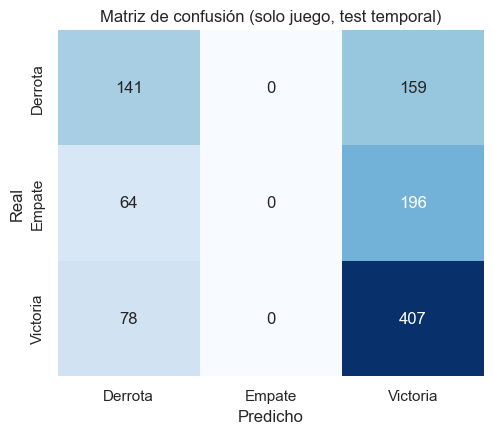

              precision    recall  f1-score   support

     Derrota       0.50      0.47      0.48       300
      Empate       0.00      0.00      0.00       260
    Victoria       0.53      0.84      0.65       485

    accuracy                           0.52      1045
   macro avg       0.34      0.44      0.38      1045
weighted avg       0.39      0.52      0.44      1045



Accuracy=0.524 | LogLoss=1.004
(El modelo completo: Accuracy=0.596 | LogLoss=0.852)


In [8]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, log_loss

pred = pipe.predict(Xte); proba = pipe.predict_proba(Xte)
cm = confusion_matrix(yte, pred, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Derrota', 'Empate', 'Victoria'], yticklabels=['Derrota', 'Empate', 'Victoria'])
ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title('Matriz de confusión (solo juego, test temporal)')
plt.show()
print(classification_report(yte, pred, labels=[0, 1, 2], target_names=['Derrota', 'Empate', 'Victoria']))
print(f'Accuracy={accuracy_score(yte, pred):.3f} | LogLoss={log_loss(yte, proba):.3f}')
print('(El modelo completo: Accuracy=0.596 | LogLoss=0.852)')

El patrón es el mismo del principal (el argmax casi nunca elige Empate) pero con menos aciertos
en Victorias/Derrotas: sin la fuerza acumulada, más partidos parecen parejos.

## 6b · Tratamiento del empate (cómo lo hacen los profesionales)

In [9]:
def rps(P, yv):
    Pc = np.cumsum(P, 1); Oc = np.cumsum(np.eye(3)[np.asarray(yv)], 1)
    return np.mean(np.sum((Pc - Oc) ** 2, 1)) / (3 - 1)

print(f'1) Calibración: P(empate) media={proba[:, 1].mean():.3f} vs tasa real={(yte == 1).mean():.3f}')
print(f'2) RPS (métrica profesional V/E/D) = {rps(proba, yte.values):.3f}  (menor=mejor; el completo: 0.162)')
for w in [None, 'balanced']:
    mm = Pipeline([('sc', StandardScaler()),
                   ('m', LogisticRegression(max_iter=2000, class_weight=w))]).fit(Xtr, ytr)
    print(f'3) class_weight={str(w):9}: {(mm.predict(Xte) == 1).sum():3d} empates predichos | '
          f'LogLoss={log_loss(yte, mm.predict_proba(Xte)):.3f}')
print('   -> forzar empates (balanced) empeora el log-loss, igual que en el modelo principal.')

1) Calibración: P(empate) media=0.281 vs tasa real=0.249
2) RPS (métrica profesional V/E/D) = 0.207  (menor=mejor; el completo: 0.162)
3) class_weight=None     :   0 empates predichos | LogLoss=1.004
3) class_weight=balanced : 139 empates predichos | LogLoss=1.038
   -> forzar empates (balanced) empeora el log-loss, igual que en el modelo principal.


## 7 · ROC y calibración (clase Victoria)

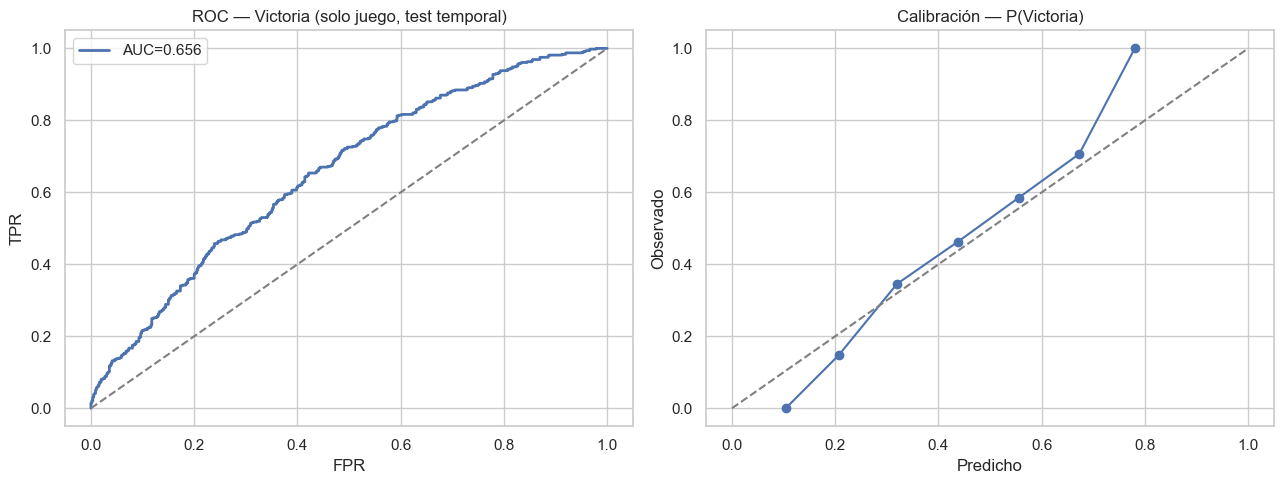

AUC (OVR macro) = 0.626   (el completo: 0.761)


In [10]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.calibration import calibration_curve

yv = (yte == 2).astype(int); pv = proba[:, 2]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(yv, pv)
ax[0].plot(fpr, tpr, lw=2, label=f'AUC={auc(fpr, tpr):.3f}'); ax[0].plot([0, 1], [0, 1], '--', color='grey')
ax[0].set_title('ROC — Victoria (solo juego, test temporal)'); ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].legend()
po, pp_ = calibration_curve(yv, pv, n_bins=8)
ax[1].plot(pp_, po, 'o-'); ax[1].plot([0, 1], [0, 1], '--', color='grey')
ax[1].set_title('Calibración — P(Victoria)'); ax[1].set_xlabel('Predicho'); ax[1].set_ylabel('Observado')
plt.tight_layout(); plt.show()
print(f"AUC (OVR macro) = {roc_auc_score(yte, proba, multi_class='ovr', average='macro'):.3f}   (el completo: 0.761)")

## 8 · Modelos alternativos (CV temporal, 5 cortes)

Idéntico torneo de modelos que el principal — dos filosofías bajo el mismo protocolo walk-forward:

- **Selección manual**: logística simple, interacciones, **SVM** (RBF), **red neuronal (MLP)** y
  **ordinal** (enlaces *logit* y *probit*) sobre el set final de 3.
- **Selección automática sobre las 7**: **Lasso**, **Ridge**, **Elastic Net** y los árboles
  (**Random Forest**, **Gradient Boosting** con early stopping, **XGBoost**).

**Ningún hiperparámetro va por defecto:** `C`, `l1_ratio`, arquitectura del MLP y profundidad/nº de
árboles del XGBoost se eligen con el mismo CV temporal. Referencias: la **logística con las 7 sin
regularizar** y — *fuera de concurso* — el **modelo completo** (elo+h2h+valor), para no perder de
vista el costo de la prohibición.

In [11]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

def _logit(**kw):
    return LogisticRegression(max_iter=4000, **kw)

def cv_ll(model, fs):
    return -cross_val_score(model, train[fs], ytr, cv=cv, scoring='neg_log_loss').mean()

def mejor_C(penalty, solver='lbfgs'):
    sc = {Cv: cv_ll(Pipeline([('sc', StandardScaler()), ('m', _logit(penalty=penalty, solver=solver, C=Cv))]), CAND)
          for Cv in [0.01, 0.03, 0.1, 0.3, 1.0]}
    Cb = min(sc, key=sc.get)
    print(f'   {penalty.upper():4} sobre las 7 -> mejor C={Cb} (log-loss {sc[Cb]:.4f})')
    return Cb

def mejor_elastic():
    sc = {(Cv, r): cv_ll(Pipeline([('sc', StandardScaler()),
                                   ('m', _logit(penalty='elasticnet', solver='saga', C=Cv, l1_ratio=r))]), CAND)
          for Cv in [0.01, 0.03, 0.1, 0.3, 1.0] for r in [0.25, 0.5, 0.75]}
    (Cb, rb) = min(sc, key=sc.get)
    print(f'   ELASTIC NET sobre las 7 -> mejor C={Cb}, l1_ratio={rb} (log-loss {sc[(Cb, rb)]:.4f})')
    return Cb, rb

def mejor_C_svm():
    sc = {Cv: cv_ll(Pipeline([('sc', StandardScaler()),
                              ('m', SVC(kernel='rbf', C=Cv, probability=True, random_state=SEED))]), FINAL)
          for Cv in [0.3, 1, 3, 10]}
    Cb = min(sc, key=sc.get)
    print(f'   SVM RBF sobre el set final -> mejor C={Cb} (log-loss {sc[Cb]:.4f})')
    return Cb

def mejor_xgb():
    sc = {}
    for d in [2, 3]:
        for n in [100, 300]:
            m = XGBClassifier(n_estimators=n, max_depth=d, learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8, objective='multi:softprob', eval_metric='mlogloss',
                              random_state=SEED, n_jobs=-1, verbosity=0)
            sc[(d, n)] = cv_ll(m, CAND)
    (db, nb) = min(sc, key=sc.get)
    print(f'   XGBOOST sobre las 7 -> mejor depth={db}, n_estimators={nb} (log-loss {sc[(db, nb)]:.4f})')
    return db, nb

def mejor_mlp():
    sc = {}
    for h in [(8,), (16, 8)]:
        for a in [1e-3, 1e-2]:
            m = Pipeline([('sc', StandardScaler()),
                          ('m', MLPClassifier(hidden_layer_sizes=h, alpha=a, max_iter=2000,
                                              early_stopping=True, n_iter_no_change=20, random_state=SEED))])
            sc[(h, a)] = cv_ll(m, FINAL)
    (hb, ab) = min(sc, key=sc.get)
    print(f'   MLP sobre el set final -> mejor hidden={hb}, alpha={ab} (log-loss {sc[(hb, ab)]:.4f})')
    return hb, ab

print('Eligiendo hiperparámetros por CV temporal:')
C_l1 = mejor_C('l1', solver='saga')
C_l2 = mejor_C('l2')
C_en, r_en = mejor_elastic()
C_svm = mejor_C_svm()
d_xgb, n_xgb = mejor_xgb()
h_mlp, a_mlp = mejor_mlp()

mods = {
    'Logística (set final, forward)': (Pipeline([('sc', StandardScaler()), ('m', _logit())]), FINAL),
    'Interacciones (set final)': (Pipeline([('sc', StandardScaler()),
                                            ('p', PolynomialFeatures(2, interaction_only=True, include_bias=False)),
                                            ('m', _logit())]), FINAL),
    f'SVM RBF (set final, C={C_svm})': (Pipeline([('sc', StandardScaler()),
                                                  ('m', SVC(kernel='rbf', C=C_svm, probability=True, random_state=SEED))]), FINAL),
    f'MLP {h_mlp} (set final)': (Pipeline([('sc', StandardScaler()),
                                           ('m', MLPClassifier(hidden_layer_sizes=h_mlp, alpha=a_mlp, max_iter=2000,
                                                               early_stopping=True, n_iter_no_change=20,
                                                               random_state=SEED))]), FINAL),
    f'Lasso (las 7, C={C_l1})': (Pipeline([('sc', StandardScaler()),
                                           ('m', _logit(penalty='l1', solver='saga', C=C_l1))]), CAND),
    f'Ridge (las 7, C={C_l2})': (Pipeline([('sc', StandardScaler()),
                                           ('m', _logit(penalty='l2', C=C_l2))]), CAND),
    f'Elastic Net (las 7, C={C_en}, r={r_en})': (Pipeline([('sc', StandardScaler()),
                                                           ('m', _logit(penalty='elasticnet', solver='saga',
                                                                        C=C_en, l1_ratio=r_en))]), CAND),
    'Random Forest (las 7)': (RandomForestClassifier(n_estimators=300, max_depth=6, random_state=SEED, n_jobs=-1), CAND),
    'Grad. Boosting (las 7, early stop)': (HistGradientBoostingClassifier(
        learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=40, max_iter=1000,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=25, random_state=SEED), CAND),
    f'XGBoost (las 7, depth={d_xgb}, n={n_xgb})': (XGBClassifier(
        n_estimators=n_xgb, max_depth=d_xgb, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob', eval_metric='mlogloss', random_state=SEED, n_jobs=-1, verbosity=0), CAND),
    'Ref: las 7 sin regularizar': (Pipeline([('sc', StandardScaler()), ('m', _logit(penalty=None))]), CAND),
    'REF FUERA DE CONCURSO: modelo completo': (Pipeline([('sc', StandardScaler()), ('m', _logit())]), COMPLETO),
}

rps_scorer = make_scorer(lambda yv_, P: rps(P, yv_), response_method='predict_proba', greater_is_better=False)
res = []
for nom, (mod, fs) in mods.items():
    s = cross_validate(mod, train[fs], ytr, cv=cv, scoring={'acc': 'accuracy', 'll': 'neg_log_loss', 'rps': rps_scorer})
    res.append({'Modelo': nom, 'Accuracy': s['test_acc'].mean(),
                'LogLoss': -s['test_ll'].mean(), 'RPS': -s['test_rps'].mean()})

# ORDINAL en sus dos enlaces (mismo CV, loop manual: statsmodels no es compatible con cross_validate)
from statsmodels.miscmodels.ordinal_model import OrderedModel
for distr, nombre_d in [('logit', 'Ordinal logit (set final)'), ('probit', 'Ordinal probit (set final)')]:
    lls, accs, rpss = [], [], []
    for tr_, va_ in cv.split(train):
        sc_ = StandardScaler().fit(train[FINAL].iloc[tr_])
        res_o = OrderedModel(ytr.values[tr_], sc_.transform(train[FINAL].iloc[tr_]), distr=distr).fit(method='bfgs', disp=0)
        P_o = np.asarray(res_o.predict(sc_.transform(train[FINAL].iloc[va_])))
        yva = ytr.values[va_]
        lls.append(log_loss(yva, P_o, labels=[0, 1, 2])); accs.append((P_o.argmax(1) == yva).mean()); rpss.append(rps(P_o, yva))
    res.append({'Modelo': nombre_d, 'Accuracy': np.mean(accs), 'LogLoss': np.mean(lls), 'RPS': np.mean(rpss)})

tabla = pd.DataFrame(res).set_index('Modelo').sort_values('LogLoss')
display(tabla.round(4).style.highlight_min(subset=['LogLoss', 'RPS'], color='lightgreen'))
best = next(n for n in tabla.index if n in mods and 'FUERA DE CONCURSO' not in n)
MODEL_BEST, FEATS_BEST = mods[best]
print(f'>>> Mejor modelo PERMITIDO por CV temporal: {best} (variables: {FEATS_BEST})')
ev_test = MODEL_BEST.fit(train[FEATS_BEST], ytr)
P_best = ev_test.predict_proba(test[FEATS_BEST])
print(f'    En test 2025-26: LogLoss={log_loss(yte, P_best):.4f} | RPS={rps(P_best, yte.values):.4f} | '
      f'Accuracy={accuracy_score(yte, P_best.argmax(1)):.4f}')

Eligiendo hiperparámetros por CV temporal:


   L1   sobre las 7 -> mejor C=0.1 (log-loss 1.0287)


   L2   sobre las 7 -> mejor C=0.01 (log-loss 1.0293)


   ELASTIC NET sobre las 7 -> mejor C=0.03, l1_ratio=0.25 (log-loss 1.0287)


   SVM RBF sobre el set final -> mejor C=0.3 (log-loss 1.0424)


   XGBOOST sobre las 7 -> mejor depth=2, n_estimators=100 (log-loss 1.0391)


   MLP sobre el set final -> mejor hidden=(16, 8), alpha=0.001 (log-loss 1.0579)


,Accuracy,LogLoss,RPS
Modelo,,,
REF FUERA DE CONCURSO: modelo completo,0.562600,0.906400,0.173400
Ordinal logit (set final),0.490500,1.026300,0.209400
Ordinal probit (set final),0.493500,1.026400,0.209300
"Logística (set final, forward)",0.489600,1.028100,0.209500
"Lasso (las 7, C=0.1)",0.488100,1.028700,0.209500
"Elastic Net (las 7, C=0.03, r=0.25)",0.488100,1.028700,0.209600
"Ridge (las 7, C=0.01)",0.482100,1.029300,0.209700
Interacciones (set final),0.487800,1.030700,0.210300
Ref: las 7 sin regularizar,0.483000,1.032200,0.210000


>>> Mejor modelo PERMITIDO por CV temporal: Logística (set final, forward) (variables: ['goles_anotados_diff', 'goles_recibidos_diff', 'tiros_arco_diff'])
    En test 2025-26: LogLoss=1.0041 | RPS=0.2069 | Accuracy=0.5244


In [12]:
# Camino de regularización del Lasso sobre las 7: orden en que caen las variables
print('Camino de selección del Lasso sobre las 7 de juego:')
for Cf in [0.002, 0.003, 0.005, 0.01, 0.03, 0.1, 0.3, 1.0]:
    m = Pipeline([('sc', StandardScaler()),
                  ('m', _logit(penalty='l1', solver='saga', C=Cf))]).fit(train[CAND], ytr)
    coefs = m.named_steps['m'].coef_
    vivas = [f for k, f in enumerate(CAND) if np.abs(coefs[:, k]).max() > 1e-8]
    caen = sorted(set(CAND) - set(vivas))
    detalle = ', '.join(vivas) if len(vivas) <= 4 else ('las 7' if not caen else f"todas menos: {', '.join(caen)}")
    marca = '   <<< C óptimo por CV (tabla)' if Cf == C_l1 else ''
    print(f'  C={Cf:<6} -> {len(vivas):2d} vivas: {detalle}{marca}')
print(f'\nForward (sección 3) había elegido: {FINAL}')

Camino de selección del Lasso sobre las 7 de juego:
  C=0.002  ->  0 vivas: 
  C=0.003  ->  2 vivas: goles_anotados_diff, goles_recibidos_diff
  C=0.005  ->  3 vivas: goles_anotados_diff, goles_recibidos_diff, posesion_diff
  C=0.01   ->  6 vivas: todas menos: faltas_diff
  C=0.03   ->  7 vivas: las 7
  C=0.1    ->  7 vivas: las 7   <<< C óptimo por CV (tabla)
  C=0.3    ->  7 vivas: las 7
  C=1.0    ->  7 vivas: las 7

Forward (sección 3) había elegido: ['goles_anotados_diff', 'goles_recibidos_diff', 'tiros_arco_diff']


**Lectura.** El cuadro replica al principal, ahora en régimen de señal débil:

1. La **referencia fuera de concurso** (modelo completo) domina la tabla con holgura — ninguna
   combinación de variables de juego, con ninguna familia de modelos, se le acerca. La información
   que prohibimos no era decorativa.
2. Entre los permitidos, las **lineales sobre el set final** lideran otra vez; árboles, boosting,
   XGBoost y la red quedan detrás — con menos señal hay aún *menos* estructura no lineal que
   explotar, solo más ruido que memorizar.
3. El **camino del Lasso** converge *parcialmente* con el forward: las dos últimas supervivientes
   son las mismas (goles anotados y recibidos — la producción manda), pero como tercera variable el
   Lasso prefiere `posesion_diff` donde el forward eligió `tiros_arco_diff`. Con señal débil, las
   variables de volumen ofensivo son casi intercambiables y el desempate entre ellas depende del
   criterio — reflejo honesto de que ninguna aporta mucho sobre la dupla de goles.

## 9 · Simulación del Mundial 2026 (Monte Carlo) — versión solo juego

El mejor modelo permitido, re-entrenado con **todos** los datos, alimenta la misma simulación del
notebook principal: para cada cruce reconstruimos las variables de juego desde `team_states.csv`
(estado al corte de junio 2026), con **simetrización** para cancha neutral, **localía de los
anfitriones** en todas sus rondas, **marcadores Poisson condicionados** al clasificador (la Poisson
también usa solo variables de juego), **terceros bien rankeados** y el **bracket oficial FIFA**
(letras verificadas contra el calendario).

In [13]:
from sklearn.base import clone
from scipy.stats import poisson
from itertools import permutations
from sklearn.pipeline import Pipeline as _Pipe

# Ponderación por K-factor: los partidos en serio pesan más que los amistosos (Mundial 3x un amistoso)
def tipo_competicion(c):
    c = str(c).lower()
    if 'amistoso' in c: return 'amistoso'
    if 'clasif' in c: return 'clasificatoria'
    if 'nations league' in c: return 'nations_league'
    if 'mundial' in c: return 'mundial'
    return 'continental'
K_FACTOR = {'amistoso': 1.0, 'clasificatoria': 2.0, 'nations_league': 2.0, 'continental': 2.5, 'mundial': 3.0}
peso_kf = data.competicion.map(tipo_competicion).map(K_FACTOR).values

final_model = clone(MODEL_BEST)
_swkey = f'{final_model.steps[-1][0]}__sample_weight' if isinstance(final_model, _Pipe) else 'sample_weight'
final_model.fit(data[FEATS_BEST], data['resultado'], **{_swkey: peso_kf})
states = pd.read_csv('../data/team_states.csv').set_index('team')

GRUPOS = {
    'A': ['Czech Republic', 'Mexico', 'South Africa', 'South Korea'],
    'B': ['Bosnia and Herzegovina', 'Canada', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Haiti', 'Morocco', 'Scotland'],
    'D': ['Australia', 'Paraguay', 'Turkey', 'United States'],
    'E': ['Curaçao', 'Ecuador', 'Germany', 'Ivory Coast'],
    'F': ['Japan', 'Netherlands', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Cape Verde', 'Saudi Arabia', 'Spain', 'Uruguay'],
    'I': ['France', 'Iraq', 'Norway', 'Senegal'],
    'J': ['Algeria', 'Argentina', 'Austria', 'Jordan'],
    'K': ['Colombia', 'DR Congo', 'Portugal', 'Uzbekistan'],
    'L': ['Croatia', 'England', 'Ghana', 'Panama'],
}
MUNDIALISTAS = [t for eqs in GRUPOS.values() for t in eqs]
ANFITRIONES = {'United States', 'Canada', 'Mexico'}


def features_cruce(a, b):
    '''Las 7 variables de juego del cruce, con `a` como local administrativo.'''
    sa, sb = states.loc[a], states.loc[b]
    return pd.DataFrame([{
        'goles_anotados_diff': sa.goles_anotados_avg - sb.goles_anotados_avg,
        'goles_recibidos_diff': sa.goles_recibidos_avg - sb.goles_recibidos_avg,
        'tiros_diff': sa.tiros_avg - sb.tiros_avg,
        'tiros_arco_diff': sa.tiros_arco_avg - sb.tiros_arco_avg,
        'corners_diff': sa.corners_avg - sb.corners_avg,
        'posesion_diff': sa.posesion_avg - sb.posesion_avg,
        'faltas_diff': sa.faltas_avg - sb.faltas_avg,
    }])


def prob_partido(a, b):
    '''[P(gana a), P(empate), P(gana b)] con simetrización; anfitriones conservan localía.'''
    pa = final_model.predict_proba(features_cruce(a, b)[FEATS_BEST])[0]
    pb = final_model.predict_proba(features_cruce(b, a)[FEATS_BEST])[0]
    va = np.array([pa[2], pa[1], pa[0]])
    vb = np.array([pb[0], pb[1], pb[2]])
    if a in ANFITRIONES and b not in ANFITRIONES: return va
    if b in ANFITRIONES and a not in ANFITRIONES: return vb
    return (va + vb) / 2


# Poisson de marcadores con las MISMAS variables de juego (todos los datos; detalle en §10)
goles = pd.read_csv('../data/espn_stats.csv', parse_dates=['fecha'])[['fecha', 'local', 'visita', 'goles_local', 'goles_visita']]
datag = data.merge(goles, on=['fecha', 'local', 'visita'], how='left')
largo_full = pd.concat([
    datag[FINAL].assign(g=datag.goles_local.values),
    (-datag[FINAL]).assign(g=datag.goles_visita.values)], ignore_index=True)
pois_engine = sm.GLM(largo_full['g'], sm.add_constant(largo_full[FINAL]), family=sm.families.Poisson()).fit()
b0s = pois_engine.params['const']; bets = pois_engine.params[FINAL].values

def lambdas_par(a, b):
    fr = features_cruce(a, b)[FINAL].values[0].astype(float)
    s = float(np.dot(bets, fr))
    return float(np.exp(b0s + s)), float(np.exp(b0s - s))


p = prob_partido('Spain', 'Argentina')
print(f'Ejemplo — España vs Argentina (neutral): {p[0]:.1%} / {p[1]:.1%} / {p[2]:.1%}')
p = prob_partido('United States', 'Paraguay')
print(f'Ejemplo — USA (anfitrión) vs Paraguay  : {p[0]:.1%} / {p[1]:.1%} / {p[2]:.1%}')
la, lb = lambdas_par('Spain', 'Jordan')
print(f'Goles esperados España vs Jordania     : {la:.2f} - {lb:.2f}')

Ejemplo — España vs Argentina (neutral): 42.8% / 27.7% / 29.5%
Ejemplo — USA (anfitrión) vs Paraguay  : 48.0% / 28.1% / 23.9%
Goles esperados España vs Jordania     : 2.42 - 0.61


### 9.1 · Partido a partido: los 72 partidos de la fase de grupos

La tabla completa queda en `predicciones_fase_grupos_solo_stats.csv`.

In [14]:
filas = []
for g, eqs in GRUPOS.items():
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = eqs[i], eqs[j]
            if b in ANFITRIONES and a not in ANFITRIONES:
                a, b = b, a
            p = prob_partido(a, b); la, lb = lambdas_par(a, b)
            filas.append({'grupo': g, 'equipo_1': a, 'equipo_2': b,
                          'cancha': 'anfitrión' if (a in ANFITRIONES) ^ (b in ANFITRIONES) else 'neutral',
                          'P(gana 1)': round(p[0], 3), 'P(empate)': round(p[1], 3), 'P(gana 2)': round(p[2], 3),
                          'goles_esp_1': round(la, 2), 'goles_esp_2': round(lb, 2)})
pred_grupos = pd.DataFrame(filas)
pred_grupos.to_csv('../outputs/predicciones_fase_grupos_solo_stats.csv', index=False)
print('Guardado: predicciones_fase_grupos_solo_stats.csv (72 partidos)')
pred_grupos.head(12)

Guardado: predicciones_fase_grupos_solo_stats.csv (72 partidos)


,grupo,equipo_1,equipo_2,cancha,P(gana 1),P(empate),P(gana 2),goles_esp_1,goles_esp_2
0,A,Mexico,Czech Republic,anfitrión,0.379,0.281,0.340,1.08,1.36
1,A,Czech Republic,South Africa,neutral,0.366,0.281,0.353,1.22,1.20
2,A,Czech Republic,South Korea,neutral,0.589,0.244,0.167,1.95,0.75
3,A,Mexico,South Africa,anfitrión,0.384,0.285,0.330,1.08,1.35
4,A,Mexico,South Korea,anfitrión,0.610,0.242,0.148,1.74,0.84
5,A,South Africa,South Korea,neutral,0.582,0.246,0.171,1.94,0.76
6,B,Canada,Bosnia and Herzegovina,anfitrión,0.350,0.269,0.381,1.02,1.44
7,B,Bosnia and Herzegovina,Qatar,neutral,0.636,0.228,0.137,2.10,0.70
8,B,Bosnia and Herzegovina,Switzerland,neutral,0.371,0.280,0.349,1.24,1.18
9,B,Canada,Qatar,anfitrión,0.618,0.246,0.136,1.77,0.83


### 9.2 · Monte Carlo (10,000 mundiales, bracket oficial FIFA de 48)

In [15]:
rng = np.random.default_rng(SEED)
GRID_MAX = 10

R32 = {
    73: ('2A', '2B'), 74: ('1E', ('3', list('ABCDF'))), 75: ('1F', '2C'), 76: ('1C', '2F'),
    77: ('1I', ('3', list('CDFGH'))), 78: ('2E', '2I'), 79: ('1A', ('3', list('CEFHI'))),
    80: ('1L', ('3', list('EHIJK'))), 81: ('1D', ('3', list('BEFIJ'))), 82: ('1G', ('3', list('AEHIJ'))),
    83: ('2K', '2L'), 84: ('1H', '2J'), 85: ('1B', ('3', list('EFGIJ'))), 86: ('1J', '2H'),
    87: ('1K', ('3', list('DEIJL'))), 88: ('2D', '2G'),
}
R16 = {89: (74, 77), 90: (73, 75), 91: (76, 78), 92: (79, 80),
       93: (83, 84), 94: (81, 82), 95: (86, 88), 96: (85, 87)}
QF = {97: (89, 90), 98: (93, 94), 99: (91, 92), 100: (95, 96)}
SF = {101: (97, 98), 102: (99, 100)}
FINAL_M = (101, 102)


def asignar_terceros(grupos_terceros):
    '''Matching bipartito máximo (Kuhn), determinista.'''
    slots = {p: sorted(set(R32[p][1][1]) & grupos_terceros) for p in R32 if isinstance(R32[p][1], tuple)}
    asign, dueno = {}, {}

    def intenta(p, visitados):
        for g in slots[p]:
            if g in visitados:
                continue
            visitados.add(g)
            if g not in dueno or intenta(dueno[g], visitados):
                dueno[g] = p; asign[p] = g
                return True
        return False

    for p in sorted(slots):
        intenta(p, set())
    for p in sorted(slots):
        if p not in asign:
            libres = sorted(set(grupos_terceros) - set(asign.values()))
            asign[p] = libres[0]
    return asign


PROBS, SCORE_DIST = {}, {}
for a, b in permutations(MUNDIALISTAS, 2):
    if (b, a) in PROBS:
        PROBS[(a, b)] = PROBS[(b, a)][::-1]
    else:
        PROBS[(a, b)] = prob_partido(a, b)
    la, lb = lambdas_par(a, b)
    grid = np.outer(poisson.pmf(np.arange(GRID_MAX + 1), la), poisson.pmf(np.arange(GRID_MAX + 1), lb))
    grid /= grid.sum()
    gi, gj = np.indices(grid.shape)
    SCORE_DIST[(a, b)] = [np.cumsum((grid * mk).ravel() / (grid * mk).sum())
                          for mk in (gi > gj, gi == gj, gi < gj)]
print(f'Matriz de {len(PROBS):,} cruces lista. P(empate) media = {np.mean([v[1] for v in PROBS.values()]):.2f}')


def simular_partido(a, b, eliminatoria=False):
    p = PROBS[(a, b)]
    u = rng.random()
    res = 0 if u < p[0] else (1 if u < p[0] + p[1] else 2)
    ga, gb = divmod(int(np.searchsorted(SCORE_DIST[(a, b)][res], rng.random())), GRID_MAX + 1)
    if res == 0: return ga, gb, a
    if res == 2: return ga, gb, b
    if eliminatoria:
        return ga, gb, (a if rng.random() < p[0] / (p[0] + p[2]) else b)
    return ga, gb, None


def jugar_grupo(equipos, partido=simular_partido):
    pts = dict.fromkeys(equipos, 0); gf = dict.fromkeys(equipos, 0); gc = dict.fromkeys(equipos, 0)
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = equipos[i], equipos[j]
            ga, gb, gan = partido(a, b)
            gf[a] += ga; gc[a] += gb; gf[b] += gb; gc[b] += ga
            if gan == a: pts[a] += 3
            elif gan == b: pts[b] += 3
            else: pts[a] += 1; pts[b] += 1
    return sorted(((t, pts[t], gf[t] - gc[t], gf[t], rng.random()) for t in equipos),
                  key=lambda x: (x[1], x[2], x[3], x[4]), reverse=True)


def jugar_mundial(partido=simular_partido):
    primeros, segundos, terceros = {}, {}, []
    for g, eqs in GRUPOS.items():
        tabla = jugar_grupo(eqs, partido)
        primeros[g], segundos[g] = tabla[0][0], tabla[1][0]
        t = tabla[2]
        terceros.append({'grupo': g, 'equipo': t[0], 'pts': t[1], 'gd': t[2], 'gf': t[3], 'rnd': t[4]})
    terceros.sort(key=lambda d: (d['pts'], d['gd'], d['gf'], d['rnd']), reverse=True)
    tercero_por_grupo = {d['grupo']: d['equipo'] for d in terceros[:8]}
    asign = asignar_terceros(set(tercero_por_grupo))

    def slot(s, n):
        if isinstance(s, tuple): return tercero_por_grupo[asign[n]]
        return primeros[s[1]] if s[0] == '1' else segundos[s[1]]

    W = {}
    for n, (sa, sb) in R32.items():
        _, _, gan = partido(slot(sa, n), slot(sb, n), eliminatoria=True)
        W[n] = gan
    for ronda in (R16, QF, SF):
        for n, (p1, p2) in ronda.items():
            _, _, gan = partido(W[p1], W[p2], eliminatoria=True)
            W[n] = gan
    finalistas = (W[FINAL_M[0]], W[FINAL_M[1]])
    _, _, campeon = partido(*finalistas, eliminatoria=True)
    return {'campeon': campeon, 'finalistas': finalistas,
            'semifinalistas': [W[p] for p in (97, 98, 99, 100)],
            'a_octavos': [W[n] for n in R32]}


N_SIMS = 10000
cont = {t: {'campeon': 0, 'final': 0, 'semi': 0, 'octavos': 0} for t in MUNDIALISTAS}
for _ in range(N_SIMS):
    r = jugar_mundial()
    cont[r['campeon']]['campeon'] += 1
    for t in set(r['finalistas']): cont[t]['final'] += 1
    for t in set(r['semifinalistas']) | set(r['finalistas']): cont[t]['semi'] += 1
    for t in set(r['a_octavos']): cont[t]['octavos'] += 1

grupo_de = {t: g for g, eqs in GRUPOS.items() for t in eqs}
res_mc = pd.DataFrame([{'Selección': t, 'grupo': grupo_de[t],
                        'P_campeon': c['campeon'] / N_SIMS, 'P_final': c['final'] / N_SIMS,
                        'P_semi': c['semi'] / N_SIMS, 'P_octavos': c['octavos'] / N_SIMS}
                       for t, c in cont.items()]).sort_values('P_campeon', ascending=False).reset_index(drop=True)
res_mc.to_csv('../outputs/probabilidades_torneo_solo_stats.csv', index=False)
print(f'{N_SIMS:,} Mundiales simulados. Guardado: probabilidades_torneo_solo_stats.csv')
display(res_mc.head(12).style.format({'P_campeon': '{:.1%}', 'P_final': '{:.1%}', 'P_semi': '{:.1%}', 'P_octavos': '{:.1%}'}))

Matriz de 2,256 cruces lista. P(empate) media = 0.26


10,000 Mundiales simulados. Guardado: probabilidades_torneo_solo_stats.csv


,Selección,grupo,P_campeon,P_final,P_semi,P_octavos
0,Belgium,G,21.5%,30.5%,42.8%,79.0%
1,Norway,I,10.6%,17.8%,29.9%,66.2%
2,Portugal,K,8.9%,16.7%,27.2%,67.9%
3,Ivory Coast,E,8.2%,14.5%,26.0%,62.7%
4,Spain,H,5.8%,10.9%,19.4%,54.7%
5,Austria,J,5.2%,10.8%,19.1%,56.3%
6,England,L,4.7%,10.1%,19.1%,62.6%
7,Algeria,J,4.3%,9.1%,16.9%,53.8%
8,Netherlands,F,2.9%,6.4%,14.0%,51.2%
9,Germany,E,2.9%,6.6%,14.4%,49.5%


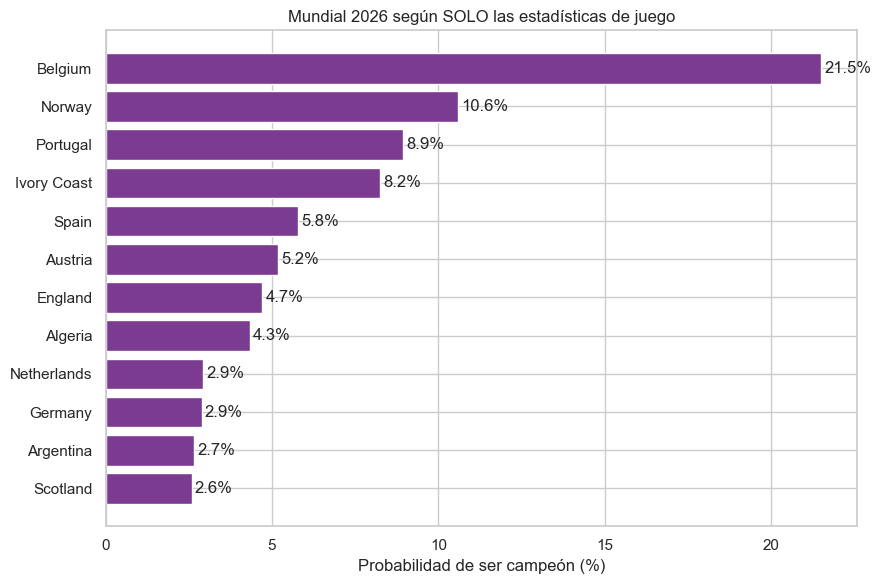

In [16]:
top = res_mc.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['Selección'], top.P_campeon * 100, color='#7a3b91')
for k, v in enumerate(top.P_campeon * 100):
    ax.text(v + 0.1, k, f'{v:.1f}%', va='center')
ax.set_xlabel('Probabilidad de ser campeón (%)')
ax.set_title('Mundial 2026 según SOLO las estadísticas de juego')
plt.tight_layout(); plt.show()

### 9.3 · Un Mundial por dentro (una realización, semilla fija)

> ⚠️ Igual que en el principal: esto es **una historia** entre 10,000, no el pronóstico.
> Cada cruce de eliminatorias muestra la probabilidad que tenía el ganador de avanzar.

In [17]:
rng = np.random.default_rng(2026)

def jugar_grupo_detallado(equipos):
    st = {t: {'Pts': 0, 'PJ': 0, 'GF': 0, 'GC': 0} for t in equipos}
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = equipos[i], equipos[j]
            ga, gb, gan = simular_partido(a, b)
            st[a]['PJ'] += 1; st[b]['PJ'] += 1
            st[a]['GF'] += ga; st[a]['GC'] += gb
            st[b]['GF'] += gb; st[b]['GC'] += ga
            if gan == a: st[a]['Pts'] += 3
            elif gan == b: st[b]['Pts'] += 3
            else: st[a]['Pts'] += 1; st[b]['Pts'] += 1
    orden = sorted(equipos, key=lambda t: (st[t]['Pts'], st[t]['GF'] - st[t]['GC'], st[t]['GF'], rng.random()),
                   reverse=True)
    return orden, st

primeros_d, segundos_d, terceros_d, filas = {}, {}, [], []
for g, eqs in GRUPOS.items():
    orden, st = jugar_grupo_detallado(eqs)
    primeros_d[g], segundos_d[g] = orden[0], orden[1]
    t3 = orden[2]
    terceros_d.append({'grupo': g, 'equipo': t3, 'pts': st[t3]['Pts'],
                       'gd': st[t3]['GF'] - st[t3]['GC'], 'gf': st[t3]['GF'], 'rnd': rng.random()})
    for pos, t in enumerate(orden, 1):
        filas.append({'Grupo': g, 'Pos': pos, 'Equipo': t, 'PJ': st[t]['PJ'], 'Pts': st[t]['Pts'],
                      'GF': st[t]['GF'], 'GC': st[t]['GC'], 'DG': st[t]['GF'] - st[t]['GC']})

display(pd.DataFrame(filas).set_index(['Grupo', 'Pos']))

terceros_d.sort(key=lambda d: (d['pts'], d['gd'], d['gf'], d['rnd']), reverse=True)
print('Ranking de terceros (clasifican los 8 primeros):')
for k, d in enumerate(terceros_d, 1):
    print(f"  {k:2d}. {d['equipo']:<24} (grupo {d['grupo']})  {d['pts']} pts, DG {d['gd']:+d}, "
          f"GF {d['gf']}  {'✅' if k <= 8 else '❌'}")
tercero_por_grupo_d = {d['grupo']: d['equipo'] for d in terceros_d[:8]}

Equipo  PJ  Pts  GF  GC  DG
Grupo Pos                                             
A     1            Czech Republic   3    7   6   4   2
      2               South Korea   3    4   5   5   0
      3              South Africa   3    4   4   4   0
      4                    Mexico   3    1   1   3  -2
B     1    Bosnia and Herzegovina   3    7   6   1   5
      2               Switzerland   3    5   4   1   3
      3                    Canada   3    4   2   3  -1
      4                     Qatar   3    0   1   8  -7
C     1                   Morocco   3    7   5   2   3
      2                    Brazil   3    4   6   3   3
      3                  Scotland   3    4   4   3   1
      4                     Haiti   3    1   1   8  -7
D     1             United States   3    6   9   2   7
      2                    Turkey   3    5   3   2   1
      3                  Paraguay   3    2   1   4  -3
      4                 Australia   3    2   2   7  -5
E     1                   Germany   3    9   6   1   5
      2                   Ecuador   3    6   7   2   5
      3               Ivory Coast   3    3   3   7  -4
      4                   Curaçao   3    0   2   8  -6
F     1                   Tunisia   3    9   9   3   6
      2               Netherlands   3    6   9   3   6
      3                     Japan   3    1   3   7  -4
      4                    Sweden   3    1   2  10  -8
G     1                   Belgium   3    7   6   3   3
      2                      Iran   3    3   0   0   0
      3                     Egypt   3    2   2   3  -1
      4               New Zealand   3    2   3   5  -2
H     1                     Spain   3    6   9   2   7
      2                Cape Verde   3    4   3   3   0
      3              Saudi Arabia   3    4   3   4  -1
      4                   Uruguay   3    3   2   8  -6
I     1                    Norway   3    5   4   2   2
      2                   Senegal   3    4   3   3   0
      3                    France   3    3   4   4   0
      4                      Iraq   3    2   3   5  -2
J     1                   Algeria   3    9   7   2   5
      2                   Austria   3    4   6   4   2
      3                 Argentina   3    3   3   6  -3
      4                    Jordan   3    1   1   5  -4
K     1                  Portugal   3    7   6   3   3
      2                Uzbekistan   3    7   4   1   3
      3                  Colombia   3    3   4   4   0
      4                  DR Congo   3    0   0   6  -6
L     1                   Croatia   3    7   4   2   2
      2                   England   3    6   8   4   4
      3                     Ghana   3    3   2   4  -2
      4                    Panama   3    1   2   6  -4

Ranking de terceros (clasifican los 8 primeros):
   1. Scotland                 (grupo C)  4 pts, DG +1, GF 4  ✅
   2. South Africa             (grupo A)  4 pts, DG +0, GF 4  ✅
   3. Saudi Arabia             (grupo H)  4 pts, DG -1, GF 3  ✅
   4. Canada                   (grupo B)  4 pts, DG -1, GF 2  ✅
   5. Colombia                 (grupo K)  3 pts, DG +0, GF 4  ✅
   6. France                   (grupo I)  3 pts, DG +0, GF 4  ✅
   7. Ghana                    (grupo L)  3 pts, DG -2, GF 2  ✅
   8. Argentina                (grupo J)  3 pts, DG -3, GF 3  ✅
   9. Ivory Coast              (grupo E)  3 pts, DG -4, GF 3  ❌
  10. Egypt                    (grupo G)  2 pts, DG -1, GF 2  ❌
  11. Paraguay                 (grupo D)  2 pts, DG -3, GF 1  ❌
  12. Japan                    (grupo F)  1 pts, DG -4, GF 3  ❌


In [18]:
asign_d = asignar_terceros(set(tercero_por_grupo_d))

def slot_d(s, n):
    if isinstance(s, tuple):
        return tercero_por_grupo_d[asign_d[n]]
    return primeros_d[s[1]] if s[0] == '1' else segundos_d[s[1]]

W = {}

def p_avance(a, b):
    p = PROBS[(a, b)]
    return p[0] + p[1] * p[0] / (p[0] + p[2])

def jugar_ronda_detallada(nombre, llaves, resolver):
    print(f'— {nombre} —')
    for n, (x, z) in llaves.items():
        a, b = resolver(x, n), resolver(z, n)
        ga, gb, gan = simular_partido(a, b, eliminatoria=True)
        pen = ' (penales)' if ga == gb else ''
        pgan = p_avance(a, b) if gan == a else 1 - p_avance(a, b)
        print(f'   {a:>24} {ga}-{gb} {b:<24}{pen} ->  {gan} (avanzaba con {pgan:.0%})')
        W[n] = gan
    print()

jugar_ronda_detallada('DIECISEISAVOS DE FINAL', R32, slot_d)
jugar_ronda_detallada('OCTAVOS DE FINAL', R16, lambda p, n: W[p])
jugar_ronda_detallada('CUARTOS DE FINAL', QF, lambda p, n: W[p])
jugar_ronda_detallada('SEMIFINALES', SF, lambda p, n: W[p])
fa, fb = W[FINAL_M[0]], W[FINAL_M[1]]
ga, gb, campeon = simular_partido(fa, fb, eliminatoria=True)
pen = ' (penales)' if ga == gb else ''
p_camp_final = p_avance(fa, fb) if campeon == fa else 1 - p_avance(fa, fb)
print(f'— FINAL —\n   {fa:>24} {ga}-{gb} {fb:<24}{pen} ->  {campeon} (ganaba la final con {p_camp_final:.0%})')
print(f'\n🏆 CAMPEÓN (en esta simulación): {campeon}')

p_camp = res_mc.set_index('Selección').loc[campeon, 'P_campeon']
top3 = res_mc.P_campeon.head(3).sum()
print(f'\nContexto: en las 10,000 simulaciones, {campeon} sale campeón el {p_camp:.1%} de las veces.')
print(f'El campeón queda FUERA del top-3 de favoritos en ~{1 - top3:.0%} de los Mundiales simulados.')

— DIECISEISAVOS DE FINAL —
                South Korea 1-3 Switzerland              ->  Switzerland (avanzaba con 76%)
                    Germany 1-0 South Africa             ->  Germany (avanzaba con 59%)
                    Tunisia 1-4 Brazil                   ->  Brazil (avanzaba con 65%)
                    Morocco 2-1 Netherlands              ->  Morocco (avanzaba con 44%)
                     Norway 2-1 Saudi Arabia             ->  Norway (avanzaba con 87%)
                    Ecuador 1-0 Senegal                  ->  Ecuador (avanzaba con 38%)
             Czech Republic 4-0 Scotland                 ->  Czech Republic (avanzaba con 43%)
                    Croatia 0-0 Colombia                 (penales) ->  Croatia (avanzaba con 66%)
              United States 1-1 Canada                   (penales) ->  Canada (avanzaba con 49%)
                    Belgium 2-0 Argentina                ->  Belgium (avanzaba con 73%)
                 Uzbekistan 2-4 England                  ->  Engl

### 9.4 · Simulador manual `versus()` — versión solo juego

Mismo simulador del principal, con el perfil del cruce mostrando las variables de juego y la
**matriz de marcadores** (rojo = más probable, verde punteado = el sorteado).

  Spain vs Argentina   —   cancha: neutral   [modelo SOLO JUEGO]
Perfil del cruce (Spain − Argentina), las variables del modelo (promedios últimos 8):
   goles_anotados_diff      +0.69    (3.12 vs 2.43)
   goles_recibidos_diff     +0.33    (1.33 vs 1.00)
   tiros_arco_diff          +1.50    (7.50 vs 6.00)

Probabilidades del clasificador solo-juego:
   Spain: 42.8%   |   Empate: 27.7%   |   Argentina: 29.5%
   Si es eliminatoria (prórroga/penales incl.): avanza Spain 59.1% / Argentina 40.9%

Goles esperados (Poisson solo-juego): Spain 1.37 — 1.07 Argentina
Marcadores más probables:
   1-1 (13.1%)   1-0 (11.7%)   0-1 (9.4%)   0-0 (8.9%)   2-1 (8.6%)

🎲 Simulación de ejemplo: Spain 1-0 Argentina



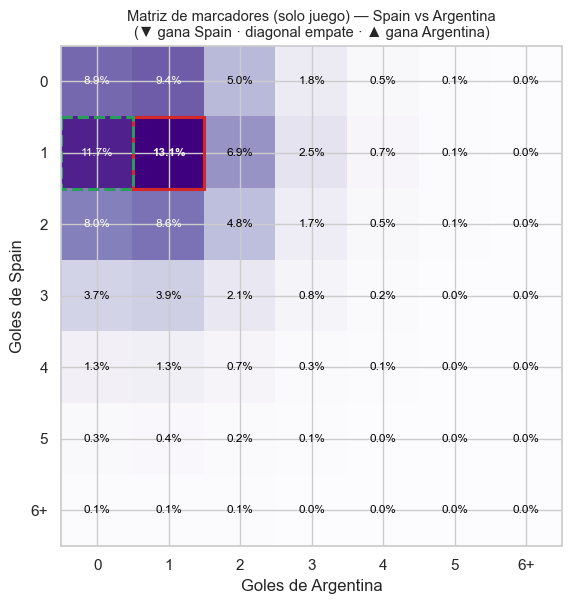

  Mexico vs Brazil   —   cancha: localía de Mexico (anfitrión del Mundial)   [modelo SOLO JUEGO]
Perfil del cruce (Mexico − Brazil), las variables del modelo (promedios últimos 8):
   goles_anotados_diff      -0.57    (2.14 vs 2.71)
   goles_recibidos_diff     -0.17    (1.50 vs 1.67)
   tiros_arco_diff          -1.50    (5.00 vs 6.50)

Probabilidades del clasificador solo-juego:
   Mexico: 36.7%   |   Empate: 27.4%   |   Brazil: 35.9%
   Si es eliminatoria (prórroga/penales incl.): avanza Mexico 50.6% / Brazil 49.4%

Goles esperados (Poisson solo-juego): Mexico 1.05 — 1.39 Brazil
Marcadores más probables:
   1-1 (13.0%)   1-0 (11.8%)   0-1 (9.7%)   0-0 (8.8%)   2-1 (8.6%)

🎲 Simulación de ejemplo: Mexico 2-0 Brazil



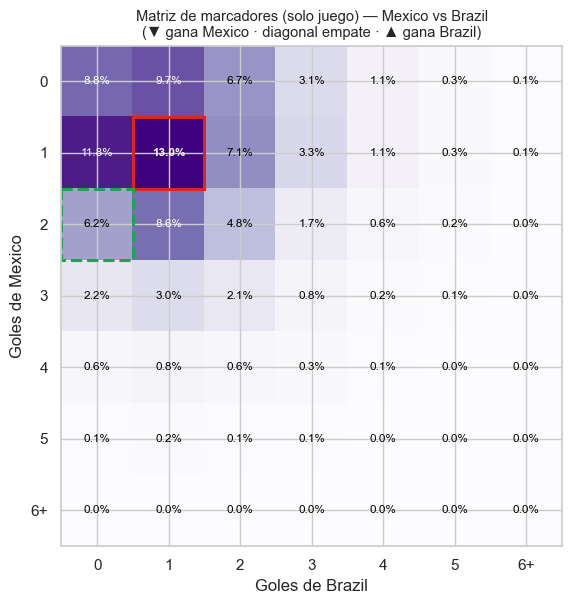

In [19]:
def versus(equipo1, equipo2, cancha='auto', semilla=None, matriz=True):
    '''Pronóstico detallado con el modelo solo-juego. cancha: 'auto'|'neutral'|'1'|'2'.'''
    for t in (equipo1, equipo2):
        if t not in states.index:
            parecidos = [s for s in states.index if t.lower() in s.lower()][:5]
            raise ValueError(f"'{t}' no está en team_states. ¿Quizás quisiste decir: {parecidos}?")
    a, b = equipo1, equipo2
    pa = final_model.predict_proba(features_cruce(a, b)[FEATS_BEST])[0]
    pb = final_model.predict_proba(features_cruce(b, a)[FEATS_BEST])[0]
    va = np.array([pa[2], pa[1], pa[0]])
    vb = np.array([pb[0], pb[1], pb[2]])
    if cancha == '1':
        p, desc = va, f'localía de {a}'
    elif cancha == '2':
        p, desc = vb, f'localía de {b}'
    elif cancha == 'auto' and a in ANFITRIONES and b not in ANFITRIONES:
        p, desc = va, f'localía de {a} (anfitrión del Mundial)'
    elif cancha == 'auto' and b in ANFITRIONES and a not in ANFITRIONES:
        p, desc = vb, f'localía de {b} (anfitrión del Mundial)'
    else:
        p, desc = (va + vb) / 2, 'neutral'

    la, lb = lambdas_par(a, b)
    g = np.arange(GRID_MAX + 1)
    grid = np.outer(poisson.pmf(g, la), poisson.pmf(g, lb)); grid /= grid.sum()
    gi, gj = np.indices(grid.shape)
    masks = (gi > gj, gi == gj, gi < gj)
    mix = sum(p[k] * (grid * mk) / (grid * mk).sum() for k, mk in enumerate(masks))

    sa, sb = states.loc[a], states.loc[b]
    print('=' * 66)
    print(f'  {a} vs {b}   —   cancha: {desc}   [modelo SOLO JUEGO]')
    print('=' * 66)
    print(f'Perfil del cruce ({a} − {b}), las variables del modelo (promedios últimos 8):')
    for f in FEATS_BEST:
        col = f.replace('_diff', '_avg')
        print(f'   {f:22} {sa[col] - sb[col]:+7.2f}    ({sa[col]:.2f} vs {sb[col]:.2f})')
    print(f'\nProbabilidades del clasificador solo-juego:')
    print(f'   {a}: {p[0]:.1%}   |   Empate: {p[1]:.1%}   |   {b}: {p[2]:.1%}')
    pkA = p[0] + p[1] * p[0] / (p[0] + p[2])
    print(f'   Si es eliminatoria (prórroga/penales incl.): avanza {a} {pkA:.1%} / {b} {1 - pkA:.1%}')
    print(f'\nGoles esperados (Poisson solo-juego): {a} {la:.2f} — {lb:.2f} {b}')
    flat = mix.ravel(); top = flat.argsort()[::-1][:5]
    print('Marcadores más probables:')
    print('   ' + '   '.join(f'{ix // (GRID_MAX + 1)}-{ix % (GRID_MAX + 1)} ({flat[ix]:.1%})' for ix in top))
    r = np.random.default_rng(semilla) if semilla is not None else rng
    u = r.random(); resu = 0 if u < p[0] else (1 if u < p[0] + p[1] else 2)
    cond = (grid * masks[resu]).ravel(); cond = cond / cond.sum()
    ga_, gb_ = divmod(int(np.searchsorted(np.cumsum(cond), r.random())), GRID_MAX + 1)
    print(f'\n🎲 Simulación de ejemplo: {a} {ga_}-{gb_} {b}\n')

    if matriz:
        m = 6
        M = np.zeros((m + 1, m + 1))
        M[:m, :m] = mix[:m, :m]
        M[m, :m] = mix[m:, :m].sum(axis=0)
        M[:m, m] = mix[:m, m:].sum(axis=1)
        M[m, m] = mix[m:, m:].sum()
        fig, ax = plt.subplots(figsize=(7.4, 6.2))
        ax.imshow(M, cmap='Purples')
        etiq = [str(i) for i in range(m)] + ['6+']
        ax.set_xticks(range(m + 1)); ax.set_xticklabels(etiq)
        ax.set_yticks(range(m + 1)); ax.set_yticklabels(etiq)
        ax.set_xlabel(f'Goles de {b}'); ax.set_ylabel(f'Goles de {a}')
        ax.set_title(f'Matriz de marcadores (solo juego) — {a} vs {b}\n'
                     f'(▼ gana {a} · diagonal empate · ▲ gana {b})', fontsize=10.5)
        imax, jmax = np.unravel_index(M.argmax(), M.shape)
        for i in range(m + 1):
            for j in range(m + 1):
                ax.text(j, i, f'{M[i, j]:.1%}', ha='center', va='center', fontsize=8.5,
                        color='white' if M[i, j] > M.max() * 0.6 else 'black',
                        fontweight='bold' if (i, j) == (imax, jmax) else 'normal')
        ax.add_patch(plt.Rectangle((jmax - 0.5, imax - 0.5), 1, 1, fill=False, edgecolor='#d62728', lw=2.2))
        ax.add_patch(plt.Rectangle((min(gb_, m) - 0.5, min(ga_, m) - 0.5), 1, 1,
                                   fill=False, edgecolor='#2a9d5c', lw=2.2, ls='--'))
        plt.tight_layout(); plt.show()


versus('Spain', 'Argentina')
versus('Mexico', 'Brazil')

## 10 · Modelo Poisson de goles (solo juego) y el torneo según la Poisson

Misma doble verificación del principal: **(a)** la Poisson con las mismas variables de juego,
entrenada en 2019–24 y comparada contra la multinomial en el test temporal (más el ensamble);
**(b)** el torneo completo re-simulado con la Poisson como único motor.

In [20]:
dtr = datag[datag.fecha < CORTE_TEST]; dte = datag[datag.fecha >= CORTE_TEST]
largo_tr = pd.concat([
    dtr[FINAL].assign(g=dtr.goles_local.values),
    (-dtr[FINAL]).assign(g=dtr.goles_visita.values)], ignore_index=True)
pois = sm.GLM(largo_tr['g'], sm.add_constant(largo_tr[FINAL]), family=sm.families.Poisson()).fit()
b0 = pois.params['const']; bet = pois.params[FINAL].values
print(pois.summary().tables[1])

def lambdas_final(fr):
    s = float(np.dot(bet, fr)); return np.exp(b0 + s), np.exp(b0 - s)

def wdl(li, lj, m=10):
    Mx = np.outer(poisson.pmf(np.arange(m + 1), li), poisson.pmf(np.arange(m + 1), lj))
    return np.array([np.triu(Mx, 1).sum(), np.trace(Mx), np.tril(Mx, -1).sum()])

pp = np.array([wdl(*lambdas_final(r)) for r in dte[FINAL].values])
pp /= pp.sum(1, keepdims=True)
pl = pipe.predict_proba(dte[FINAL]); yv_ = dte.resultado.values
pe = (pl + pp) / 2
comp = pd.DataFrame({'Modelo': ['Logística multinomial', 'Poisson de goles', 'Ensamble (promedio)'],
                     'Accuracy': [accuracy_score(yv_, P.argmax(1)) for P in (pl, pp, pe)],
                     'LogLoss': [log_loss(yv_, P) for P in (pl, pp, pe)],
                     'RPS': [rps(P, yv_) for P in (pl, pp, pe)]}).set_index('Modelo')
display(comp.round(4).style.highlight_min(subset=['LogLoss', 'RPS'], color='lightgreen'))

                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.1695      0.011     16.106      0.000       0.149       0.190
goles_anotados_diff      0.1653      0.010     16.303      0.000       0.145       0.185
goles_recibidos_diff    -0.2262      0.011    -20.119      0.000      -0.248      -0.204
tiros_arco_diff          0.0460      0.006      8.253      0.000       0.035       0.057


,Accuracy,LogLoss,RPS
Modelo,,,
Logística multinomial,0.524400,1.004100,0.206900
Poisson de goles,0.492800,1.024600,0.214300
Ensamble (promedio),0.511000,1.008200,0.208700


In [21]:
# Torneo con motor Poisson puro (mismas variables de juego, grillas desde la Poisson de §9)
gidx = np.arange(GRID_MAX + 1)
PROBS_P, SCORE_P = {}, {}
for a, b in permutations(MUNDIALISTAS, 2):
    la, lb = lambdas_par(a, b)
    grid = np.outer(poisson.pmf(gidx, la), poisson.pmf(gidx, lb)); grid /= grid.sum()
    gi, gj = np.indices(grid.shape)
    PROBS_P[(a, b)] = np.array([(grid * (gi > gj)).sum(), np.trace(grid), (grid * (gi < gj)).sum()])
    SCORE_P[(a, b)] = np.cumsum(grid.ravel())


def simular_partido_poisson(a, b, eliminatoria=False):
    ga, gb = divmod(int(np.searchsorted(SCORE_P[(a, b)], rng.random())), GRID_MAX + 1)
    if ga > gb: return ga, gb, a
    if gb > ga: return ga, gb, b
    if eliminatoria:
        p = PROBS_P[(a, b)]
        return ga, gb, (a if rng.random() < p[0] / (p[0] + p[2]) else b)
    return ga, gb, None


rng = np.random.default_rng(SEED)
cont_p = {t: {'campeon': 0, 'final': 0, 'semi': 0, 'octavos': 0} for t in MUNDIALISTAS}
for _ in range(N_SIMS):
    r = jugar_mundial(partido=simular_partido_poisson)
    cont_p[r['campeon']]['campeon'] += 1
    for t in set(r['finalistas']): cont_p[t]['final'] += 1
    for t in set(r['semifinalistas']) | set(r['finalistas']): cont_p[t]['semi'] += 1
    for t in set(r['a_octavos']): cont_p[t]['octavos'] += 1

res_pois = pd.DataFrame([{'Selección': t, 'grupo': grupo_de[t],
                          'P_campeon': c['campeon'] / N_SIMS, 'P_final': c['final'] / N_SIMS,
                          'P_semi': c['semi'] / N_SIMS, 'P_octavos': c['octavos'] / N_SIMS}
                         for t, c in cont_p.items()]).sort_values('P_campeon', ascending=False).reset_index(drop=True)
res_pois.to_csv('../outputs/probabilidades_torneo_poisson_solo_stats.csv', index=False)
print(f'{N_SIMS:,} Mundiales con motor Poisson. Guardado: probabilidades_torneo_poisson_solo_stats.csv')

from scipy.stats import spearmanr
cmp_ = res_mc[['Selección', 'P_campeon']].merge(res_pois[['Selección', 'P_campeon']],
                                                on='Selección', suffixes=('_logit', '_poisson'))
print(f"Correlación P(campeón) logit vs poisson (ambos solo-juego): "
      f"Pearson {cmp_.P_campeon_logit.corr(cmp_.P_campeon_poisson):.3f} | "
      f"Spearman {spearmanr(cmp_.P_campeon_logit, cmp_.P_campeon_poisson).statistic:.3f}")

10,000 Mundiales con motor Poisson. Guardado: probabilidades_torneo_poisson_solo_stats.csv
Correlación P(campeón) logit vs poisson (ambos solo-juego): Pearson 0.996 | Spearman 0.975


## 11 · El duelo final: Mundial "solo juego" vs Mundial del modelo completo

La pregunta del experimento, respondida en el terreno que importa: ¿cambia el pronóstico del torneo?
Cargamos las probabilidades del notebook principal (`probabilidades_torneo.csv`) y las enfrentamos
con las de este modelo.

Correlación P(campeón): Pearson 0.193 | Spearman (orden) 0.658
Concentración del top-5: completo 76.1% vs solo juego 55.1%



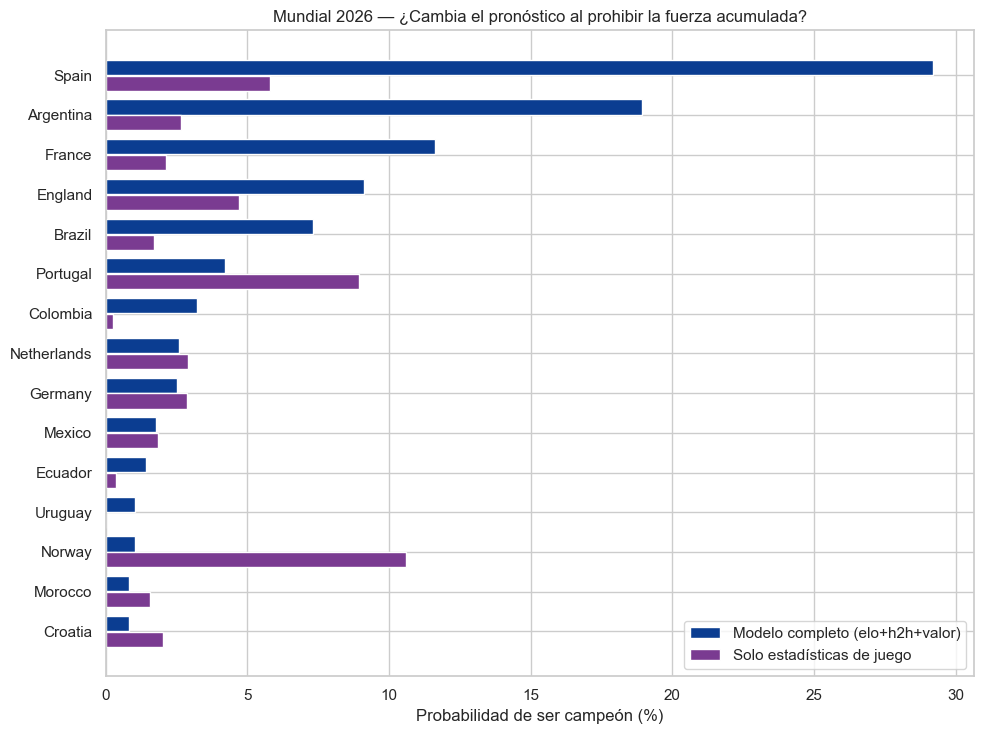

Mayores diferencias (P campeón):


,Selección,grupo,P_completo,P_solo_juego,dif (completo − solo juego)
0,Spain,H,0.2918,0.0579,0.2339
1,Belgium,G,0.0075,0.2151,-0.2076
2,Argentina,J,0.1892,0.0266,0.1626
3,Norway,I,0.0104,0.1058,-0.0954
4,France,I,0.1162,0.0213,0.0949
5,Ivory Coast,E,0.0003,0.0825,-0.0822
6,Brazil,C,0.0732,0.0172,0.0560
7,Austria,J,0.0012,0.0517,-0.0505
8,Portugal,K,0.0420,0.0893,-0.0473
9,England,L,0.0910,0.0471,0.0439


In [22]:
res_full = pd.read_csv('../outputs/probabilidades_torneo.csv')   # el Mundial del modelo completo
duelo = res_full[['Selección', 'grupo', 'P_campeon']].rename(columns={'P_campeon': 'P_completo'}).merge(
    res_mc[['Selección', 'P_campeon']].rename(columns={'P_campeon': 'P_solo_juego'}), on='Selección')
duelo['dif (completo − solo juego)'] = duelo.P_completo - duelo.P_solo_juego

from scipy.stats import spearmanr
print(f"Correlación P(campeón): Pearson {duelo.P_completo.corr(duelo.P_solo_juego):.3f} | "
      f"Spearman (orden) {spearmanr(duelo.P_completo, duelo.P_solo_juego).statistic:.3f}")
print(f"Concentración del top-5: completo {duelo.nlargest(5, 'P_completo').P_completo.sum():.1%} "
      f"vs solo juego {duelo.nlargest(5, 'P_solo_juego').P_solo_juego.sum():.1%}\n")

top = duelo.sort_values('P_completo', ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7.5))
ypos = np.arange(len(top))
ax.barh(ypos + 0.2, top.P_completo * 100, height=0.38, color='#0b3d91', label='Modelo completo (elo+h2h+valor)')
ax.barh(ypos - 0.2, top.P_solo_juego * 100, height=0.38, color='#7a3b91', label='Solo estadísticas de juego')
ax.set_yticks(ypos); ax.set_yticklabels(top['Selección'])
ax.set_xlabel('Probabilidad de ser campeón (%)')
ax.set_title('Mundial 2026 — ¿Cambia el pronóstico al prohibir la fuerza acumulada?')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

print('Mayores diferencias (P campeón):')
dif = duelo.reindex(duelo['dif (completo − solo juego)'].abs().sort_values(ascending=False).index).head(10)
display(dif.round(4).reset_index(drop=True))

**Lectura.** El modelo solo-juego no solo *aplana* el pronóstico (el top-5 concentra mucha menos
probabilidad y el torneo parece más lotería) — **cambia de protagonistas**: el favorito pasa a ser
Bélgica, con Noruega, Costa de Marfil, Austria o Argelia trepando al grupo de candidatos, mientras
España se desinfla y Argentina desaparece de la conversación.

¿Por qué? Los promedios de box score **no están ajustados por la calidad del rival**. Una selección
que llega de golear a rivales menores en su clasificatoria continental exhibe números enormes de
goles y tiros — y este modelo se los cree. El Elo, en cambio, es *opponent-adjusted por
construcción*: ganarle 5-0 a un débil mueve poco el rating. Esa corrección es exactamente la
información que aquí nos prohibimos, y su ausencia es la principal fuente de distorsión (la
correlación de Pearson con el pronóstico completo se desploma, aunque el orden grueso — Spearman —
conserva relación). Junto con el test de §4 (log-loss 1.00 vs 0.85), la conclusión es nítida: **el
box score reciente aporta señal real pero limitada y mal calibrada entre confederaciones; lo que más
sabe del futuro de un partido es la historia acumulada de fuerza ajustada por rival**.

## 12 · Conclusiones del experimento

**Lo que se mantiene (robustez metodológica):** el protocolo completo se replicó sin tocar nada —
validación temporal, forward + VIF + significancia, 14 modelos con hiperparámetros por CV, Poisson de
contraste, simulación con simetrización y bracket oficial. Y los patrones estructurales se repiten:
los datos vuelven a elegir **3 variables** (ataque, defensa, pegada), las lineales vuelven a ganarle
a árboles/boosting/red, el Lasso vuelve a converger con el forward, y la Poisson vuelve a coincidir
con la multinomial. La metodología es estable ante un cambio radical de menú de variables.

**Lo que cambia (el hallazgo):**
- **Predicción de partidos:** log-loss ~1.00 en test vs 0.85 del completo; accuracy 52% vs 60%;
  AUC ~0.65 vs 0.76. Mejor que el azar y que las frecuencias — la forma del box score *existe* como
  señal — pero la mayor parte de lo predecible vive en la **fuerza acumulada** (Elo, plantilla, H2H).
- **El torneo se aplana:** sin ratings, los favoritos concentran mucha menos probabilidad y el
  Mundial parece más lotería de lo que el modelo completo (y las casas de apuestas) creen que es.
- Posesión, córners, tiros totales y faltas no aportan sobre goles y tiros al arco: **el volumen sin
  puntería no predice**.

**Moraleja del experimento:** las estadísticas de juego recientes describen *cómo* juega un equipo,
pero la pregunta "¿quién gana?" la responde mejor *cuánto ha ganado históricamente y con qué
plantel*. Ambas miradas se complementan — y por eso el modelo completo, que las combina, es el
entregable principal.

*Proyecto personal — hecho con datos, rigor y fútbol.* ⚽